In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def F(a,y):
  res = np.zeros(3)
  res[0] = a[0]*(y[1]-y[0])
  res[1] = ((a[2]-a[0])*y[0] - y[0]*y[2] + a[2]*y[1])
  res[2] = (y[0]*y[1] - a[1]*y[2])

  return res



def mapa(a,x,h):
  '''são as constantes de nossos a,b e c que irão determinar as condições de nosso problema
     x,y,z é um vetor com 3 entradas do nosso mapa.

     retorna x_new,y_new,z_new'''
  k1 = F(a,x)
  k2 = F(a,x + k1*(h/2))
  k3 = F(a,x + k2*(h/2))
  k4 = F(a,x + h*k3)
  x = x + h*(k1 + 2*k2 + 2*k3 + k4)/6

  return x

def dist(x,y):
  d = np.max(np.abs(x-y))
  return d

def norma(x):
  d = np.max(np.abs(x))
  return d

In [3]:
def fecho_orbita(a,x,h,epsilon):
  '''fecho == False ==> Limitada
  fecho == True ==> Divergiu'''
  fecho = False
  T_trans = 20
  N = int(T_trans/h)

  T_real = 40
  M = int(T_real/h)

  sol = np.zeros([M,len(x)])
  tran = np.copy(x)# condição inicial do transiente

  for i in range(1,N):
    tran = mapa(a,tran,h) # aqui atualizamos o transiente em 10^5 passos de tempo
  sol[0,:] = tran # definimos o inicio de nossa solução
  for i in range(1,M):
    sol[i,:] = mapa(a,sol[i-1,:],h) #gravamos toda a trajetória evoluindo com RK44
    if dist(sol[0,:],sol[i,:]) < epsilon: # verificamos se a orbita 'fecha' ou não
      break
    elif norma(sol[i,:]) > 10**4 : # verificamos se diverge ou não
      fecho = True
      break
  return fecho,sol

In [21]:
a = np.array([40.0, 3.5, 33])
h = 0.001
epsilon = 10**-5

cond_ini1 = np.array([-0.07532533,-0.25,-0.6])#p1


cond_ini3 = np.array([-0.21796797,-0.25,-0.6])#p1'

cond_ini4 = np.array([0.22397397,    0.03828829,-0.6])#p2

cond_ini5 = np.array([-0.25000000,   -0.04079079,-0.6])#p2'



cond_ini7 = np.array([-0.12187187,   -0.04229229,-0.6])#p3


valor1, sol1 = fecho_orbita(a, cond_ini1, h, epsilon)

valor1, sol3 = fecho_orbita(a, cond_ini3, h, epsilon)
valor1, sol4 = fecho_orbita(a, cond_ini4, h, epsilon)
valor1, sol5 = fecho_orbita(a, cond_ini5, h, epsilon)

valor1, sol7 = fecho_orbita(a, cond_ini7, h, epsilon)

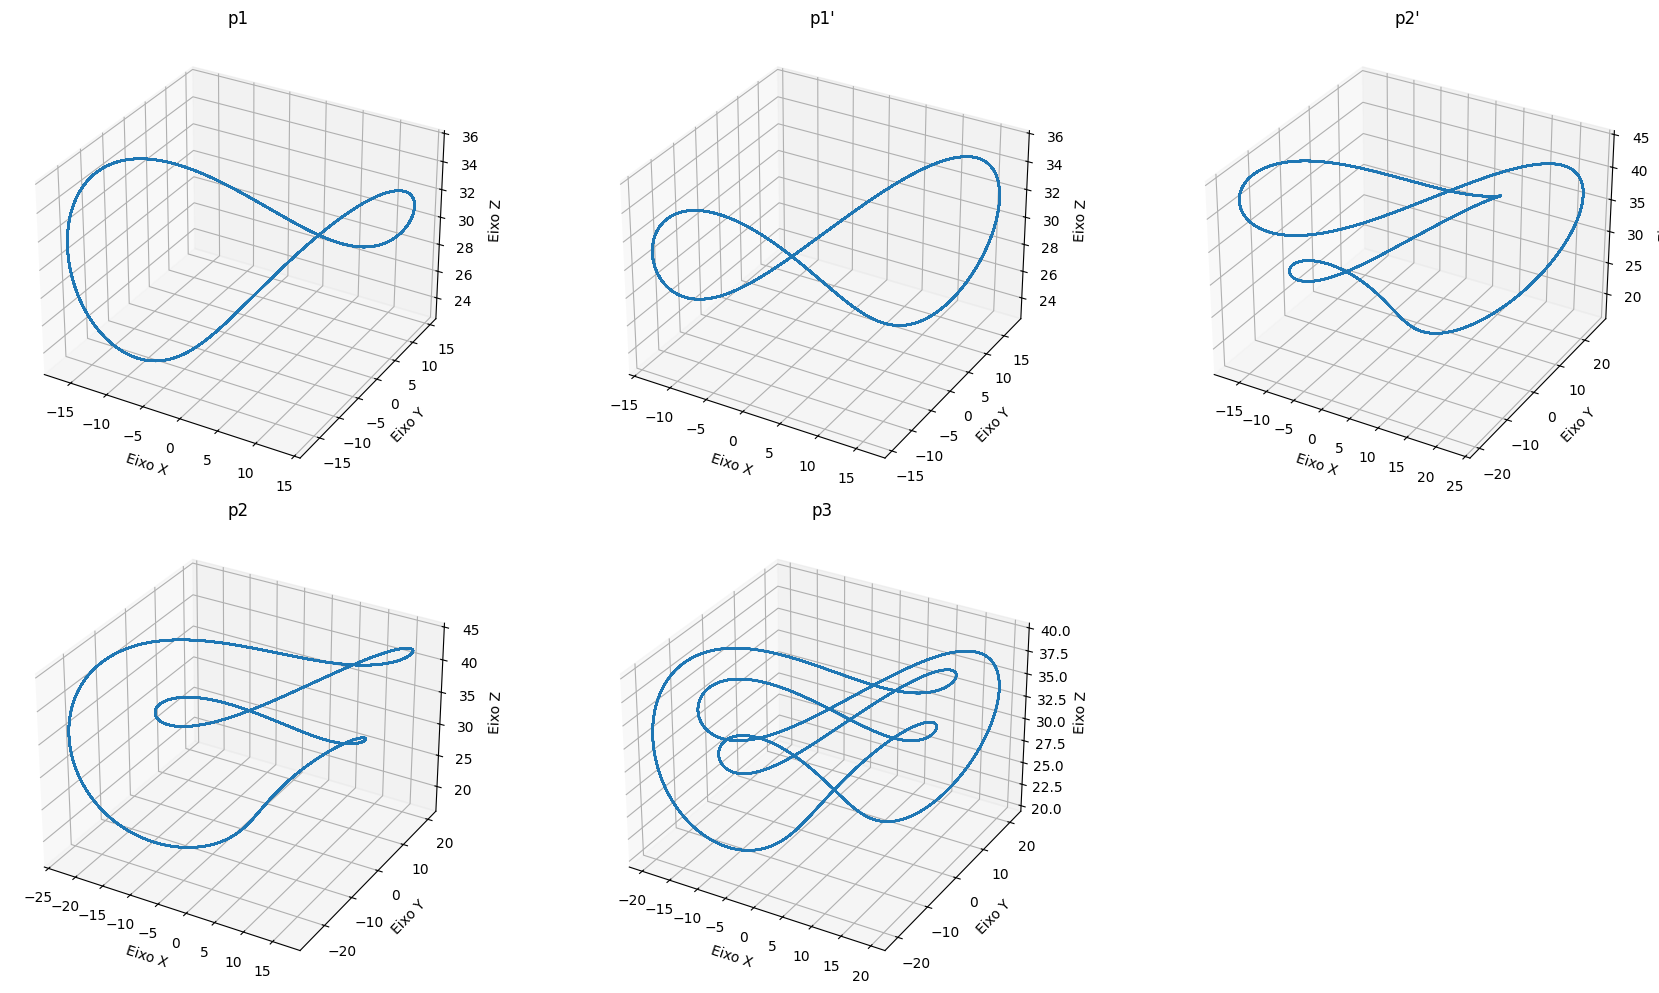

In [26]:
fig = plt.figure(figsize=(18, 10))

# Lista das soluções e títulos
solucoes = [sol1, sol3, sol4, sol5, sol7]
titulos = ['p1', "p1'", "p2'", 'p2', 'p3']

# Cria os 5 subplots
for i, (sol, titulo) in enumerate(zip(solucoes, titulos), start=1):
    ax = fig.add_subplot(2, 3, i, projection='3d')
    
    ax.plot(sol[:,0], sol[:,1], sol[:,2], label='Trajetória')
    
    ax.set_title(titulo)
    ax.set_xlabel('Eixo X')
    ax.set_ylabel('Eixo Y')
    ax.set_zlabel('Eixo Z')

# Ajusta espaçamento
plt.tight_layout()

# Exibe tudo em uma única figura
plt.show()